# Dichotomie et logarithme

## Minimum global

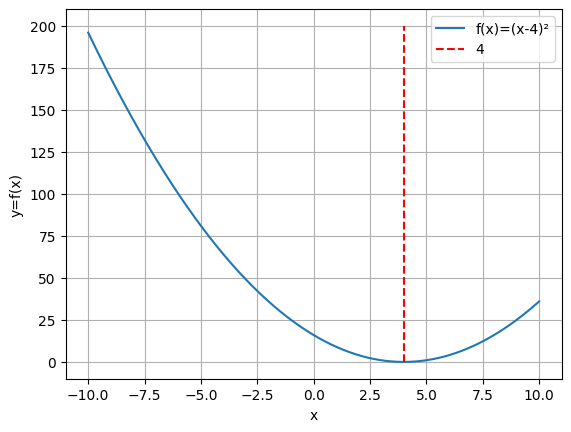

In [46]:
from matplotlib import pyplot as plt
import numpy as np
import math
x = np.linspace(-10, 10, 1000)
y = [(i - 4)**2 for i in x]
plt.plot(x, y, label='f(x)=(x-4)²')
plt.vlines(4, ymin=0, ymax=200, color='red', linestyles='dashed', label='4')
plt.legend()
plt.xlabel("x")
plt.ylabel("y=f(x)")
plt.grid() 
plt.savefig("minimum.pdf")

En utilisant un algorithme dichotomique, trouver le minimum global de la fonction **y=f(x)=x^2 - 4**. Pour cela, trouver le minimum de la liste **y** qui contient les valeurs de f(x) pour x allant de -10 à 10.

In [68]:
def trouver_minimum(liste: list):
    gauche = 0
    droite = len(liste) - 1

    while gauche < droite:
        milieu = (gauche + droite) // 2
        
        # On compare l'élément du milieu avec son voisin de droite
        if liste[milieu] > liste[milieu + 1]:
            # La pente descend vers la droite, le minimum est après milieu
            gauche = milieu + 1
        else:
            # La pente remonte (ou est plate), le minimum est à gauche ou c'est milieu
            droite = milieu
            
    return liste[gauche]


In [47]:
l = [1,2,3,4,5,6,7,8,9]
print(l[3:])
print(l[:3])

[4, 5, 6, 7, 8, 9]
[1, 2, 3]


In [69]:
print(trouver_minimum(y))

3.607210814417592e-05


**Mettre en place un protocole pour mesurer la complexité en pratique de votre algorithme.**

Quelle est la complexité empirique de cet algorithme ?

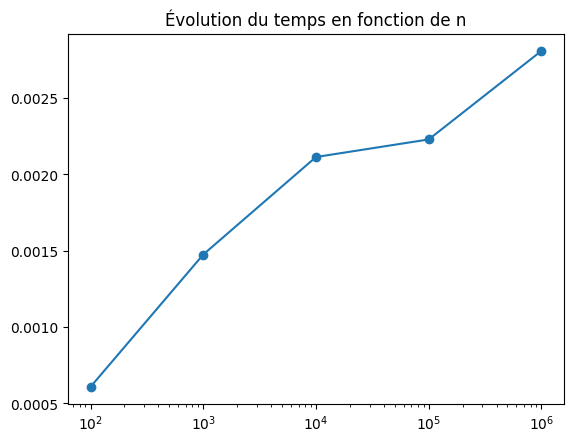

In [79]:
import timeit
import numpy as np

tailles = [100, 1000, 10000, 100000, 1000000]
resultats = []

for n in tailles:
    x_test = np.linspace(-10, 10, n)
    y_test = [(i - 4)**2 for i in x_test]
    
    t = timeit.timeit(lambda: trouver_minimum(y_test), number=1000)
    resultats.append(t)

# Affichage du graph
import matplotlib.pyplot as plt
plt.plot(tailles, resultats, marker='o')
plt.xscale('log') # On utilise une échelle log pour mieux voir
plt.title("Évolution du temps en fonction de n")
plt.show()

## f(x) = 0 ? Racine

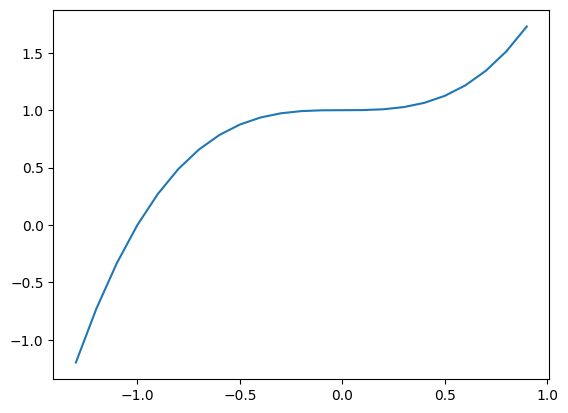

In [80]:
def f(x):
    return x**3+1

import numpy as np
import matplotlib.pyplot as plt
xs = [x for x in np.arange(-1.3,1, 0.1)]
ys = [f(x) for x in xs]
plt.plot(xs, ys)
plt.show()

On suppose une fonction $f$ continue sur l'intervalle [a, b] telle que f(a) et f(b) soient de signes opposés. D'après le théorème des valeurs intermédiaires, $f$ a au moins un zéro dans l’intervalle [a, b].
Concevoir un algorithme en complexité logarithmique pour trouver un intervalle $[min_{dicho}, max_{dicho}]$ tel que f(x)=0 se trouve dans cet intervalle et que la différence entre les deux bornes de cet intervalle est inférieur à un paramètre $precision$.

In [81]:
def trouver_intervalle(fonction, a: float, b: float, precision: float):
    # On vérifie d'abord que f(a) et f(b) sont de signes opposés
    if fonction(a) * fonction(b) > 0:
        print("Erreur : f(a) et f(b) doivent être de signes opposés.")
        return None

    while (b - a) > precision:
        milieu = (a + b) / 2
        
        # Si le produit est négatif, le signe change entre 'a' et 'milieu'
        if fonction(a) * fonction(milieu) <= 0:
            b = milieu
        else:
            # Sinon, le signe change entre 'milieu' et 'b'
            a = milieu
            
    return [a, b]

In [82]:
trouver_intervalle(f, -5, -1, 0.01)

[-1.0078125, -1]

**Mettre en place un protocole pour mesurer la complexité en pratique de votre algorithme.**

Quelle est la complexité de cet algorithme ?

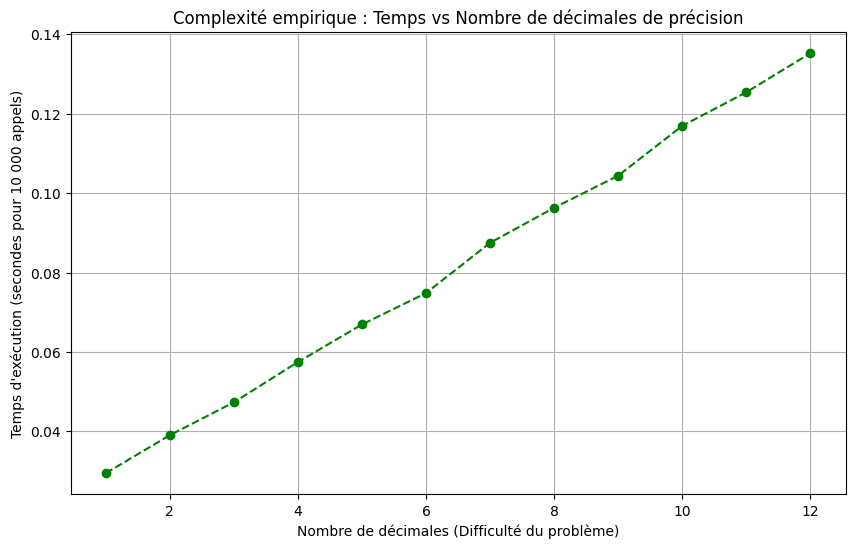

In [85]:
exposants = np.arange(1, 13)
precisions = [10**(-float(i)) for i in exposants]
temps_execution = []

# 3. Mesure du temps (Complexité Empirique)
for p in precisions:
    # On mesure le temps pour 10 000 exécutions afin d'avoir un résultat stable
    t = timeit.timeit(lambda: trouver_intervalle(f, -5, 2, p), number=10000)
    temps_execution.append(t)

# 4. Affichage des résultats
plt.figure(figsize=(10, 6))
plt.plot(exposants, temps_execution, marker='o', color='green', linestyle='--')
plt.title("Complexité empirique : Temps vs Nombre de décimales de précision")
plt.xlabel("Nombre de décimales (Difficulté du problème)")
plt.ylabel("Temps d'exécution (secondes pour 10 000 appels)")
plt.grid(True)
plt.show()

## Kd-Tree
Un **kd-arbre** (*k-dimensional tree*) est une structure de données utilisée pour organiser des points dans un espace à k dimensions. Il est particulièrement utile pour les recherches de proximité, comme la recherche de plus proches voisins de coordonnées géographiques, pour la recommandations de film/article/produits, et en IA de manière générale.

## Fonctionnement d'un kd-arbre

Un kd-arbre est un arbre binaire où chaque nœud divise l'espace selon un axe choisi cycliquement parmi les dimensions. Il suit ces règles :

1. Chaque nœud stocke un point et un axe de séparation.
2. Les points à gauche du nœud ont une valeur inférieure sur l'axe choisi.
3. Les points à droite du nœud ont une valeur supérieure ou égale.
4. La construction se fait récursivement en alternant les axes.


### Exemple détaillé de construction

Nous allons construire un kd-arbre avec les villes suivantes :

| Ville    | Coordonnées (Latitude, Longitude) |
|----------|----------------------------------|
| Paris    | (48.8566, 2.3522)               |
| Lyon     | (45.764, 4.8357)                |
| Toulouse | (43.6045, 1.444)                |
| Lille    | (50.6292, 3.0573)               |
| Nantes   | (47.2184, -1.5536)              |

1. **Profondeur 0** (Axe 0 : Latitude)
   - Tri : [(43.6045, 1.444), (45.764, 4.8357), (47.2184, -1.5536), (48.8566, 2.3522), (50.6292, 3.0573)]
   - Médiane : (47.2184, -1.5536) → Racine

2. **Profondeur 1** (Axe 1 : Longitude)
   - Sous-arbre gauche : [(43.6045, 1.444), (45.764, 4.8357)]
   - Médiane : (45.764, 4.8357) → Fils gauche de la racine
   - Sous-arbre droit : [(48.8566, 2.3522), (50.6292, 3.0573)]
   - Médiane : (48.8566, 2.3522) → Fils droit de la racine

3. **Profondeur 2** (Axe 0 : Latitude)
   - Sous-arbre gauche du fils gauche : [(43.6045, 1.444)] → Fils gauche de (45.764, 4.8357)
   - Sous-arbre gauche du fils droit : [(50.6292, 3.0573)] → Fils droit de (48.8566, 2.3522)

L'arbre final aura cette structure :
```
        (47.2184, -1.5536) [Racine]
       /                      \
(45.764, 4.8357)          (48.8566, 2.3522)
    /                            \
(43.6045, 1.444)          (50.6292, 3.0573)
```


### Mesurer le temps de recherche dans le kd-tree

Le Kd-arbres sont implémentés dans [Scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html). Tester l'efficacité d'une recherche de plus proche voisin avec la distance de [Manhattan](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cityblock.html#scipy.spatial.distance.cityblock) en utilisant cette structure de données par rapport à un stockage dans une liste classique.
Pour ce faire, nous vous donnons un moyen de générer facilement *nb_data* en 2 dimensions aléatoirement. Vous pouvez ensuite reproduire la méthodologie de mesures étudiées dans le TP1.

In [86]:
import random
nb_data = 1000
def get_data(nb_data):
    return [(random.randint(0, 100000),random.randint(0, 100000)) for i in range(nb_data)]
data = get_data(nb_data)
data[:10]

[(1731, 83704),
 (77642, 73708),
 (36306, 18405),
 (50842, 20060),
 (23242, 84820),
 (70501, 57321),
 (12451, 73287),
 (93434, 76344),
 (44173, 97362),
 (8759, 43513)]

In [87]:
from scipy.spatial import KDTree
tree = KDTree(data)

In [94]:
import time

# 1. Générer des données de test (1000 points à rechercher)
nb_recherche = 1000
donnees_test = get_data(nb_recherche)

# 2. Mesurer le temps de recherche
debut = time.perf_counter_ns()

# On recherche le plus proche voisin pour chaque point de test
# query() renvoie (distance, index)
tree.query(donnees_test)

fin = time.perf_counter_ns()

# 3. Calculer et afficher le temps écoulé
kd_tree_elapsed = fin - debut
print(f"{kd_tree_elapsed} ns")

929600 ns


In [93]:
import time
import math

# 1. On utilise les mêmes données de test que pour le KD-Tree
# (donnees_test générées précédemment)

debut_liste = time.perf_counter_ns()

for cible in donnees_test:
    # Recherche du plus proche voisin par force brute
    meilleure_dist = float('inf')
    for p in data:
        # Distance euclidienne (équivalent à ce que fait le KD-Tree par défaut)
        d = math.dist(p, cible)
        if d < meilleure_dist:
            meilleure_dist = d

fin_liste = time.perf_counter_ns()
list_elapsed = fin_liste - debut_liste
print(f"{list_elapsed} ns")

189235848 ns


In [98]:
print("Le temps d'exécution pour le kd tree est de :", kd_tree_elapsed / list_elapsed, "% de celui de la liste")

Le temps d'exécution pour le kd tree est de : 0.004912388481488983 % de celui de la liste


**À vous de jouer**

Dans la cellule suivante, faites le nécessaire pour observer la complexité de recherche dans le kd-tree empiriquement. Qu'en dites vous par rapport à ce qui a été vu théoriquement ?

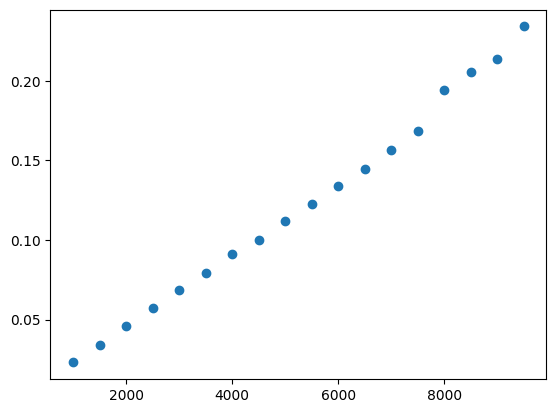

In [100]:
temps=[]
range_ = list(range(1000, 10000, 500))
data = get_data(100000)
tree = KDTree(data)
for nb_lookup in range_:
    data_lookup = [(random.randint(0, 100000),random.randint(0, 100000)) for i in range(nb_lookup)]
    debut = time.perf_counter()
    for point in data_lookup:
        tree.query(point)
    fin = time.perf_counter()    
    kd_tree_elapsed = fin - debut
    temps.append(kd_tree_elapsed)
import matplotlib.pyplot as plt
plt.scatter(range_, temps)

## Implémentation d'un kd-tree

Pour implémenter votre kd-tree, vous avez l'exemple ci-dessus, mais également des spécifications ci-dessous.

### Spécification en pseudo-code

```plaintext
KDNode
    FONCTION creer_noeud(point, axe, gauche, droite):
        RETOURNER (point, axe, gauche, droite)
      
KDTree
    FONCTION choisir_axe(profondeur, k):
        RETOURNER profondeur % k

    FONCTION calculer_mediane(points, axe):
        TRIER points SELON axe
        RETOURNER points[longueur(points) // 2]

    FONCTION construire_kd_arbre(points, labels, profondeur=0):
    
        k = dimensionnalité de points
        axe = choisir_axe(profondeur, k)
        mediane = calculer_mediane(points, axe)
        index_mediane = index(points, mediane)
    
        gauche = construire_kd_arbre(partie à gauche de la médiane des points, profondeur + 1)
        droite = construire_kd_arbre(partie droite des points, profondeur + 1)
    
        noeud = creer_noeud(mediane, axe, gauche, droite, label_mediane)
    
```

### Comment l'utiliser ?

```
### Exemple de test avec des villes françaises
points = [
    ((48.8566, 2.3522), "Paris"),
    ((45.764, 4.8357), "Lyon"),
    ((43.6045, 1.444), "Toulouse"),
    ((50.6292, 3.0573),  "Lille"),
    ((47.2184, -1.5536), "Nantes"),
    ((48.0061, 0.1996),  "Le Mans"),
    ((47.4784, -0.5632), "Angers"),
    ((48.1173, -1.6778), "Rennes"),
    ((46.1603, -1.1511), "La Rochelle"),
    ((51.0344, 2.3768),  "Dunkerque"),
    ((43.2951, -0.3708), "Pau"),
    ((43.1242, 5.928),   "Toulon"),
    ((43.2965, 5.3698),  "Marseille"),
    ((48.6921, 6.1844),  "Nancy"),
    ((48.5734, 7.7521),   "Strasbourg"),
]


kd_arbre = KDTree(points)
```
Vos données sont donc des tuples dont la premier élément est un tuple représentant les coordonnées géographiques, et le second, un label décrivant la donnée.


In [134]:
from typing import List, Tuple, Optional
import math

class KDNode:
    def __init__(self, point: Tuple[Tuple[float, float],str], axe: int, gauche: Optional['KDNode'] = None, droite: Optional['KDNode'] = None):
        """
        Initialise un nœud du kd-arbre.
        :param point: Coordonnées du point (x, y)
        :param axe: Axe de séparation (0 pour x, 1 pour y)
        :param gauche: Fils gauche du nœud
        :param droite: Fils droit du nœud
        :param label: Nom ou étiquette associée au point
        """
        self.point = point[0]
        self.axe = axe
        self.gauche = gauche
        self.droite = droite
        self.label = point[1]
        
    def __repr__(self):
        return f"Point {self.point}, label {self.label}, axe {self.axe}"

class KDTree:
    def __init__(self, points: List[Tuple[Tuple[float, float], str]]):
        """
        Initialise un kd-arbre à partir d'une liste de points et de leurs labels.
        :param points: Liste des coordonnées des points
        :param labels: Liste des étiquettes associées aux points
        """
        self.racine = self.construire_kd_arbre(points)
        
    def __repr__(self):
        return self.racine.__repr__()
    
    def choisir_axe(self, profondeur: int, k: int) -> int:
        """
        Sélectionne l'axe de division en fonction de la profondeur.
        Utilise le modulo pour alterner cycliquement entre les dimensions. [cite : 1]
        """
        return profondeur % k

    def calculer_mediane(self, points: List[Tuple[Tuple[float, float], str]], axe: int) -> Tuple[Tuple[float, float], str]:
        """
        Calcule la médiane des points selon un axe donné.
        Trie les points selon l'axe (0 ou 1) et renvoie l'élément central. [cite : 1]
        """
        # On trie la liste de tuples en se basant sur la coordonnée à l'index 'axe'
        points.sort(key=lambda x: x[0][axe])
        
        # On renvoie le point au milieu de la liste triée
        return points[len(points) // 2]

    def construire_kd_arbre(self, points: List[Tuple[Tuple[float, float], str]], profondeur: int = 0) -> Optional[KDNode]:
        """
        Construit récursivement le kd-arbre.
        Divise l'espace en deux à chaque étape selon la médiane. [cite : 1]
        """
        # Condition d'arrêt : s'il n'y a plus de points à organiser
        if not points:
            return None

        # 1. Déterminer la dimensionnalité (k=2 ici) et choisir l'axe [cite : 1]
        k = len(points[0][0])
        axe = self.choisir_axe(profondeur, k)

        # 2. Trouver le point médian pour ce niveau [cite : 1]
        mediane = self.calculer_mediane(points, axe)
        index_mediane = points.index(mediane)

        # 3. Construire récursivement les fils gauche et droit [cite : 1]
        # Le fils gauche reçoit les points inférieurs à la médiane sur l'axe choisi [cite : 1]
        gauche = self.construire_kd_arbre(points[:index_mediane], profondeur + 1)
        
        # Le fils droit reçoit les points supérieurs ou égaux [cite : 1]
        droite = self.construire_kd_arbre(points[index_mediane + 1:], profondeur + 1)

        # 4. Créer et retourner le nœud actuel [cite : 1]
        return KDNode(mediane, axe, gauche, droite)
    
    def trouver_plus_proche(self, cible: Tuple[Tuple[float, float], str], noeud: Optional[KDNode], profondeur: int = 0, meilleur: Optional[KDNode] = None) -> Optional[KDNode]:
        """
        Recherche du point le plus proche dans l'arbre.
        :param noeud: Nœud actuel
        :param cible: Point de référence
        :param profondeur: Profondeur actuelle
        :param meilleur: Meilleur candidat trouvé jusqu'à présent
        :return: Le nœud le plus proche du point cible
        """
        if noeud is None:
            return meilleur
        distance_courante = math.dist(noeud.point, cible[0])
        distance_meilleur = math.dist(meilleur.point, cible[0]) if meilleur else float('inf')
        
        if distance_courante < distance_meilleur:
            meilleur = noeud
        
        axe = self.choisir_axe(profondeur, len(cible[0]))
        prochain = noeud.gauche if cible[0][axe] < noeud.point[axe] else noeud.droite
        meilleur = self.trouver_plus_proche(cible, prochain, profondeur + 1, meilleur)
        
        if abs(noeud.point[axe] - cible[0][axe]) < math.dist(meilleur.point, cible[0]):
            autre = noeud.droite if prochain is noeud.gauche else noeud.gauche
            meilleur = self.trouver_plus_proche( cible, autre, profondeur + 1, meilleur)
        
        return meilleur

In [138]:
### Exemple de test avec des villes françaises
points = [
    ((48.8589385,2.2646341), "Paris"),
    ((43.2803706,5.0510138),  "Marseille"),
    ((45.7580409,4.7527237), "Lyon"),
    ((43.6007981,1.3504423), "Toulouse"),
    ((43.7032522,7.1704118), "Nice"),
    ((47.2383203,-1.6427346), "Nantes"),
    ((43.6100629,3.8329699), "Montpellier"),
    ((48.5691677,7.6796696),   "Strasbourg"),
    ((44.8637713,-0.6272116), "Bordeaux"),
    ((50.6311278,3.0056408),  "Lille"),
    ((48.1159843,-1.729647), "Rennes"),
    #((48.0061, 0.1996),  "Le Mans"),
    #((47.4784, -0.5632), "Angers"),
    #((46.1620876,-1.2176814), "La Rochelle"),
    #((51.0344, 2.3768),  "Dunkerque"),
    #((43.2951, -0.3708), "Pau"),
    #((43.1242, 5.928),   "Toulon"),
    #((48.6921, 6.1844),  "Nancy"),
]


kd_arbre = KDTree(points)

In [139]:
kd_arbre

Point (45.7580409, 4.7527237), label Lyon, axe 0

In [140]:
print(f"Brest: {kd_arbre.trouver_plus_proche(((48.4085046,-4.5408241),"Brest"), noeud = kd_arbre.racine)}")
print(f"Calais: {kd_arbre.trouver_plus_proche(((50.9523508,1.8277822),"Calais"), noeud = kd_arbre.racine)}")
print(f"Caen: {kd_arbre.trouver_plus_proche(((49.1846899,-0.413442),"Caen"), noeud = kd_arbre.racine)}")
print(f"Plymouth: {kd_arbre.trouver_plus_proche(((50.3885245,-4.1949699),"Plymouth"), noeud = kd_arbre.racine)}")
print(f"Poitiers: {kd_arbre.trouver_plus_proche(((46.584682,0.3302627),"Poitiers"), noeud = kd_arbre.racine)}")
print(f"Albi: {kd_arbre.trouver_plus_proche(((43.9290875,2.0911055),"Albi"), noeud = kd_arbre.racine)}")
print(f"Monaco-Ville: {kd_arbre.trouver_plus_proche(((3.7383398,7.4141553),"Monaco"), noeud = kd_arbre.racine)}")
print(f"Andorre-La-Vielle: {kd_arbre.trouver_plus_proche(((42.5125842,1.4983689),"Andorre-La-Vielle"), noeud = kd_arbre.racine)}")
print(f"Dijon: {kd_arbre.trouver_plus_proche(((47.3319205,4.9910197),"Dijon"), noeud = kd_arbre.racine)}")
print(f"Bâle-Ville: {kd_arbre.trouver_plus_proche(((47.5546368,7.5532082),"Bâle"), noeud = kd_arbre.racine)}")
print(f"Avignon: {kd_arbre.trouver_plus_proche(((43.9416105,4.7920581),"Avignon"), noeud = kd_arbre.racine)}")
print(f"Brive-La-Gaillarde: {kd_arbre.trouver_plus_proche(((45.1450666,1.4731744),"Brive-La-Gaillarde"), noeud = kd_arbre.racine)}")
print(f"Clermont-Ferrand: {kd_arbre.trouver_plus_proche(((45.7871015,3.0715219),"Clermont-Ferrand"), noeud = kd_arbre.racine)}")
print(f"Limoges: {kd_arbre.trouver_plus_proche(((45.8586117,1.1494864),"Limoges"), noeud = kd_arbre.racine)}")



Brest: Point (48.1159843, -1.729647), label Rennes, axe 0
Calais: Point (50.6311278, 3.0056408), label Lille, axe 0
Caen: Point (48.1159843, -1.729647), label Rennes, axe 0
Plymouth: Point (48.1159843, -1.729647), label Rennes, axe 0
Poitiers: Point (44.8637713, -0.6272116), label Bordeaux, axe 0
Albi: Point (43.6007981, 1.3504423), label Toulouse, axe 1
Monaco-Ville: Point (43.2803706, 5.0510138), label Marseille, axe 1
Andorre-La-Vielle: Point (43.6007981, 1.3504423), label Toulouse, axe 1
Dijon: Point (45.7580409, 4.7527237), label Lyon, axe 0
Bâle-Ville: Point (48.5691677, 7.6796696), label Strasbourg, axe 1
Avignon: Point (43.2803706, 5.0510138), label Marseille, axe 1
Brive-La-Gaillarde: Point (43.6007981, 1.3504423), label Toulouse, axe 1
Clermont-Ferrand: Point (45.7580409, 4.7527237), label Lyon, axe 0
Limoges: Point (44.8637713, -0.6272116), label Bordeaux, axe 0


## Liste triée (corrections de TD 2)

In [105]:
def recherchedico(l, val, debut=0):
    if len(l) == 0:
        return -1
    pos = len(l) // 2
    if l[pos] == val:
        return debut + pos
    elif l[pos] > val:
        return recherchedico(l[:pos], val, debut=debut)
    else:
        return recherchedico(l[pos+1:], val, debut=debut+pos+1)
    
def posdico(l, val, debut=0):
    if len(l) == 0:
        return debut
    if len(l) ==1:
        #print("ici",val, debut)
        if val < l[0]:
            return debut
        elif val == l[0]:
            return debut
        else:
            return debut+1
    pos = len(l) // 2
    if l[pos] == val:
        return pos + debut
    elif l[pos] > val:
        return posdico(l[:pos], val, debut=debut)
    else:
        return posdico(l[pos+1:], val, debut=debut+pos+1)
    
def insert(l, val):
    if len(l) == 0:
        return [val]
    pos = posdico(l,val)
    #print(l, val, pos)
    return l[:pos]+[val]+l[pos:]

def delete(l, val):
    pos = recherchedico(l, val)
    if (pos == -1):
        return l
    else:
        return l[:pos] +l[pos+1:]


In [106]:
l = list()
for i in range(100):
    l=insert(l,np.random.randint(0,100))
l

[0,
 0,
 1,
 1,
 3,
 4,
 4,
 5,
 5,
 5,
 7,
 8,
 10,
 10,
 10,
 11,
 14,
 15,
 18,
 21,
 22,
 22,
 22,
 24,
 25,
 26,
 29,
 29,
 31,
 32,
 32,
 33,
 35,
 36,
 37,
 39,
 41,
 42,
 43,
 43,
 44,
 44,
 44,
 46,
 47,
 50,
 50,
 50,
 51,
 51,
 52,
 52,
 53,
 54,
 54,
 54,
 56,
 59,
 59,
 59,
 60,
 61,
 62,
 63,
 65,
 65,
 70,
 71,
 73,
 74,
 74,
 75,
 75,
 78,
 78,
 81,
 81,
 81,
 82,
 84,
 84,
 85,
 85,
 86,
 88,
 89,
 90,
 92,
 92,
 93,
 93,
 94,
 94,
 95,
 96,
 97,
 98,
 98,
 98,
 99]